# Data Analysis Interview Challenge

## Part 1 ‐ Exploratory data analysis

The attached logins.json file contains (simulated) timestamps of user logins in a particular
geographic location. Aggregate these login counts based on 15minute
time intervals, and
visualize and describe the resulting time series of login counts in ways that best characterize the
underlying patterns of the demand. Please report/illustrate important features of the demand,
such as daily cycles. If there are data quality issues, please report them.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
%matplotlib inline

In [5]:
# Read in the data to a variable called logins 
logins = pd.read_json("./logins.json")

In [6]:
# Review the data 
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [7]:
# Review the shape 
logins.shape

(93142, 1)

In [8]:
# Review data types 
logins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


In [9]:
logins.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


In [10]:
# Check for missing values 
logins.isnull().sum()

login_time    0
dtype: int64

In [11]:
print("Missing login times:", logins['login_time'].isnull().sum())

Missing login times: 0


##### Note - No missing values 

In [13]:
# Check the range date 
print("Earliest login:", logins['login_time'].min())
print("Latest login:", logins['login_time'].max())

Earliest login: 1970-01-01 20:12:16
Latest login: 1970-04-13 18:57:38


In [14]:
date_range = logins['login_time'].max() - logins['login_time'].min()

print("Total time span:", date_range)

Total time span: 101 days 22:45:22


In [15]:
# Check for duplicates 
logins.duplicated().sum()

877

##### Note - There are 877 duplicates but multiple users could have logged in at the same time, so keeping them in for now

In [17]:
# Sort the data 
logins = logins.sort_values('login_time')

In [18]:
logins = logins.reset_index(drop=True)

In [19]:
logins.head()

,login_time
0,1970-01-01 20:12:16
1,1970-01-01 20:13:18
2,1970-01-01 20:16:10
3,1970-01-01 20:16:36
4,1970-01-01 20:16:37


In [20]:
# Aggregate logins into 15-minute intervals
logins_15min = logins.set_index('login_time').resample('15min').size()

In [21]:
logins_15min = logins_15min.reset_index()

In [22]:
logins_15min.columns = ['time_interval', 'login_count']

In [23]:
logins_15min.head()

,time_interval,login_count
0,1970-01-01 20:00:00,2
1,1970-01-01 20:15:00,6
2,1970-01-01 20:30:00,9
3,1970-01-01 20:45:00,7
4,1970-01-01 21:00:00,1


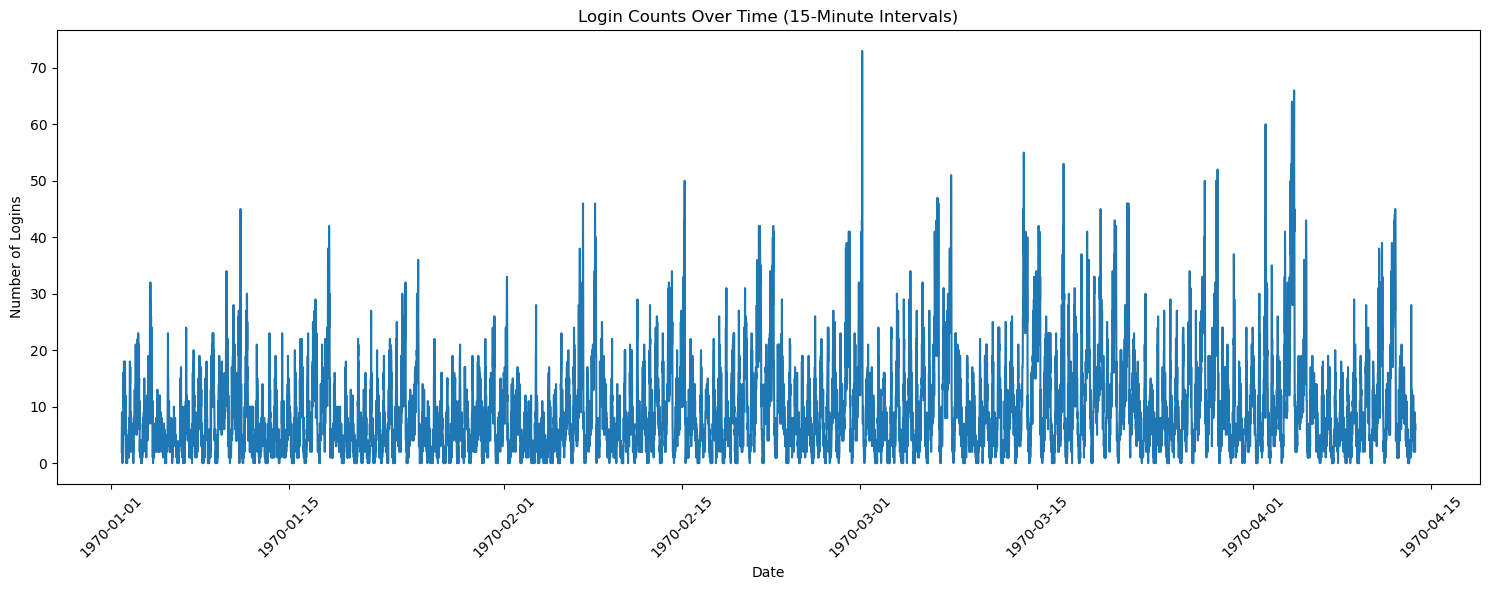

In [24]:
# Plot the complete time series 
plt.figure(figsize=(15, 6))

plt.plot(
    logins_15min['time_interval'],
    logins_15min['login_count']
)

plt.title('Login Counts Over Time (15-Minute Intervals)')
plt.xlabel('Date')
plt.ylabel('Number of Logins')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [25]:
# Add daily and hourly information

# Create day of the week variable  
logins_15min['day_of_week'] = logins_15min['time_interval'].dt.day_name()

In [26]:
# Create hour variable 
logins_15min['hour'] = logins_15min['time_interval'].dt.hour

In [27]:
# Create numerical day variable
logins_15min['day_number'] = logins_15min['time_interval'].dt.dayofweek

In [28]:
# Create day variable 
logins_15min['date'] = logins_15min['time_interval'].dt.date

In [29]:
# Create week number variable 
logins_15min['week'] = logins_15min['time_interval'].dt.isocalendar().week

In [30]:
# Analyze the daily cycle 
hourly_pattern = logins_15min.groupby('hour')['login_count'].mean()

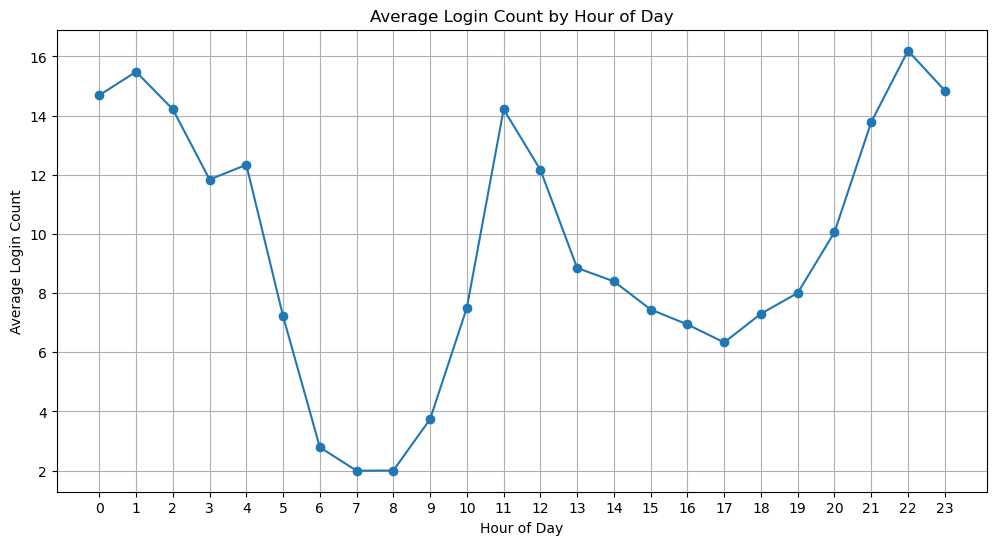

In [31]:
# Visualize the daily cycle
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker='o'
)

plt.title('Average Login Count by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Login Count')

plt.xticks(range(24))

plt.grid(True)

plt.show()

##### Observations for Average login count by hour of day 
1. Login activity is highest during the late evening and early morning hours.
2. The overall peak occurs at approximately 10 PM (hour 22), with an average of about 16 logins per 15-minute interval.
3. There is another period of high activity between approximately midnight and 2 AM, with the local peak around 1 AM.
4. Login activity drops substantially after about 4–5 AM.
5. The lowest activity occurs around 7–8 AM, with only about 2 logins per 15-minute interval on average.
6. Demand then begins increasing again during the morning, with a noticeable spike around 11 AM.
7. After the late-morning peak, activity generally declines through the afternoon, reaching another relatively low point around 5 PM.
8. Login activity then steadily increases again during the evening, leading to the highest demand around 10 PM.

In [33]:
# Analyze patterns by day of the week
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [34]:
daily_pattern = (
    logins_15min
    .groupby('day_of_week')['login_count']
    .mean()
    .reindex(day_order)
)

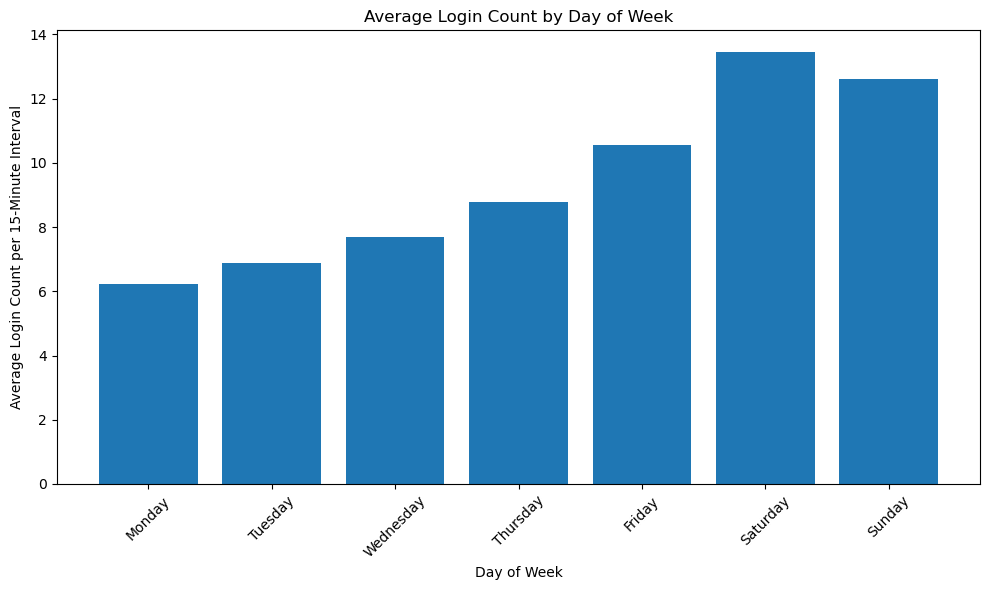

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(
    daily_pattern.index,
    daily_pattern.values
)

plt.title('Average Login Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Login Count per 15-Minute Interval')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

##### Observations
1. The average number of logins per 15-minute interval generally increases throughout the week:
- Monday has the lowest average demand, at approximately 6 logins per 15-minute interval.
- Demand gradually increases from Monday through Friday.
- Saturday has the highest average login activity, at approximately 13.5 logins per 15-minute interval.
- Sunday is the second-highest day, at approximately 12.5–13 logins per interval.
- Therefore, overall demand is noticeably higher during the weekend than during the beginning of the workweek.

In [37]:
# Compare hourly patterns across days of the week
daily_hourly = logins_15min.pivot_table(
    index='hour',
    columns='day_of_week',
    values='login_count',
    aggfunc='mean'
)

In [38]:
daily_hourly = daily_hourly[day_order]

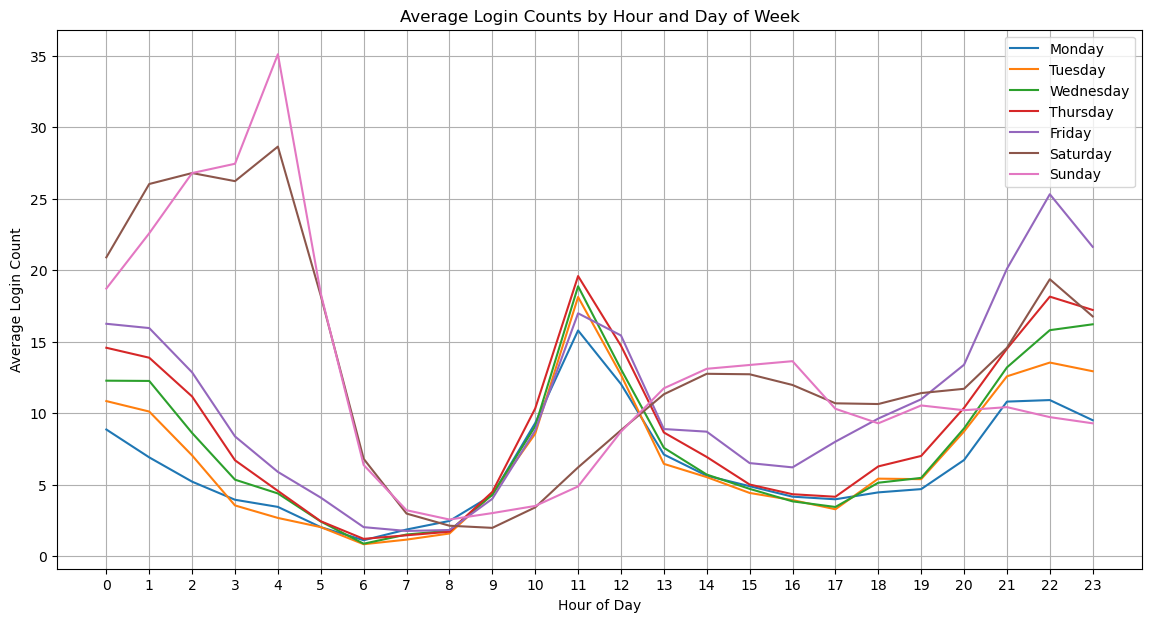

In [39]:
plt.figure(figsize=(14, 7))

for day in day_order:
    plt.plot(
        daily_hourly.index,
        daily_hourly[day],
        label=day
    )

plt.title('Average Login Counts by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Average Login Count')

plt.xticks(range(24))

plt.legend()

plt.grid(True)

plt.show()

##### Observations. 

1. Weekday patterns: 
- Login counts tend to be relatively low during the early morning hours, particularly around 6–9 AM.
- Most weekdays show a noticeable increase around 10–12 AM, with a peak near 11 AM.
- Activity generally declines again during the afternoon.
- Login demand begins increasing again during the evening, especially after approximately 6–8 PM.
- Thursday and Friday show particularly strong increases during the late evening.

2. Saturday patterns: 
- Very high activity from midnight through approximately 4 AM.
- A particularly strong peak around 4 AM, reaching close to 29 logins per 15-minute interval.
- A sharp decline after approximately 5 AM.
- Moderate activity throughout much of the afternoon and evening.
- Another significant increase around 9–11 PM, with a peak near 10 PM.

3. Sunday patterns: 
- Activity rises from midnight and reaches the highest value observed in the entire graph around 4 AM, approximately 35 logins per 15-minute interval.
- Demand then drops sharply after approximately 5 AM.
- Sunday has relatively moderate activity through much of the afternoon.
- Unlike Saturday, Sunday does not show as dramatic a late-evening spike.

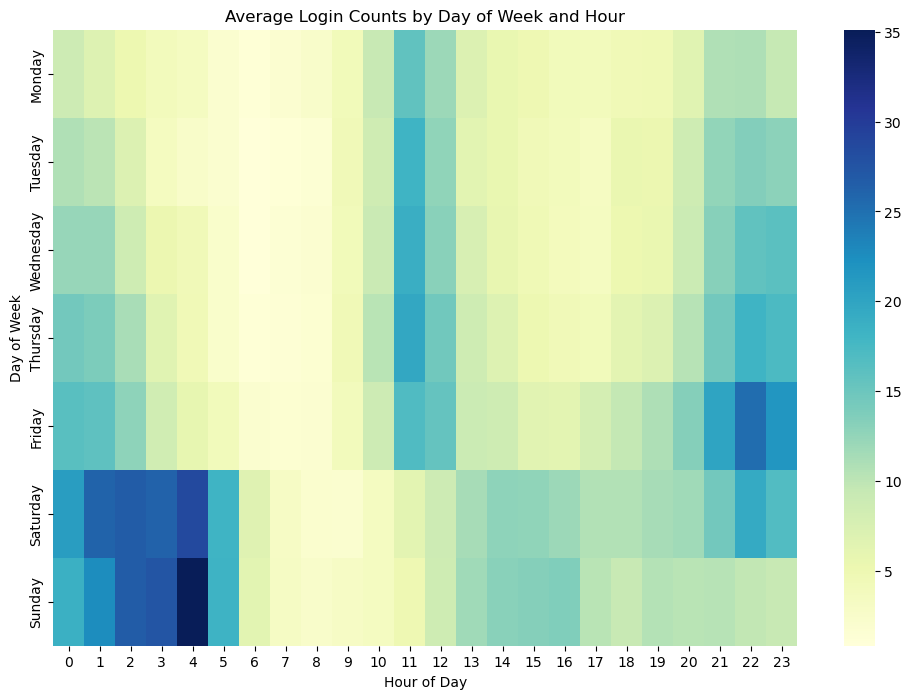

In [41]:
# Create a heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    daily_hourly.T,
    cmap='YlGnBu'
)

plt.title('Average Login Counts by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.show()

##### Observations

1. Login activity is generally lowest during the early morning hours, particularly between approximately 6 AM and 9 AM, across most days of the week.
2. A noticeable increase in activity occurs around 10 AM to 12 PM, with 11 AM showing relatively high login demand across all days.
3. Login demand is generally higher during the evening and late-night hours, although the exact pattern varies by day.
4. Friday and Saturday show particularly strong late-evening activity, with elevated login counts around 10 PM.
5. The most pronounced pattern occurs during the weekend, especially in the early morning hours. Saturday and Sunday show substantially higher login activity between approximately midnight and 5 AM compared with weekdays.
6. The highest average login count occurs on Sunday around 4 AM, followed by similarly elevated activity during the early hours of Saturday.
   
Overall, the heatmap confirms that login demand is influenced by both time of day and day of week, with the strongest demand occurring during late-night/early-morning weekend hours and lower demand occurring during the early morning hours on weekdays.

In [43]:
# Create and visualize the daily total login time series
daily_logins = (
    logins_15min
    .set_index('time_interval')
    .resample('D')['login_count']
    .sum()
)

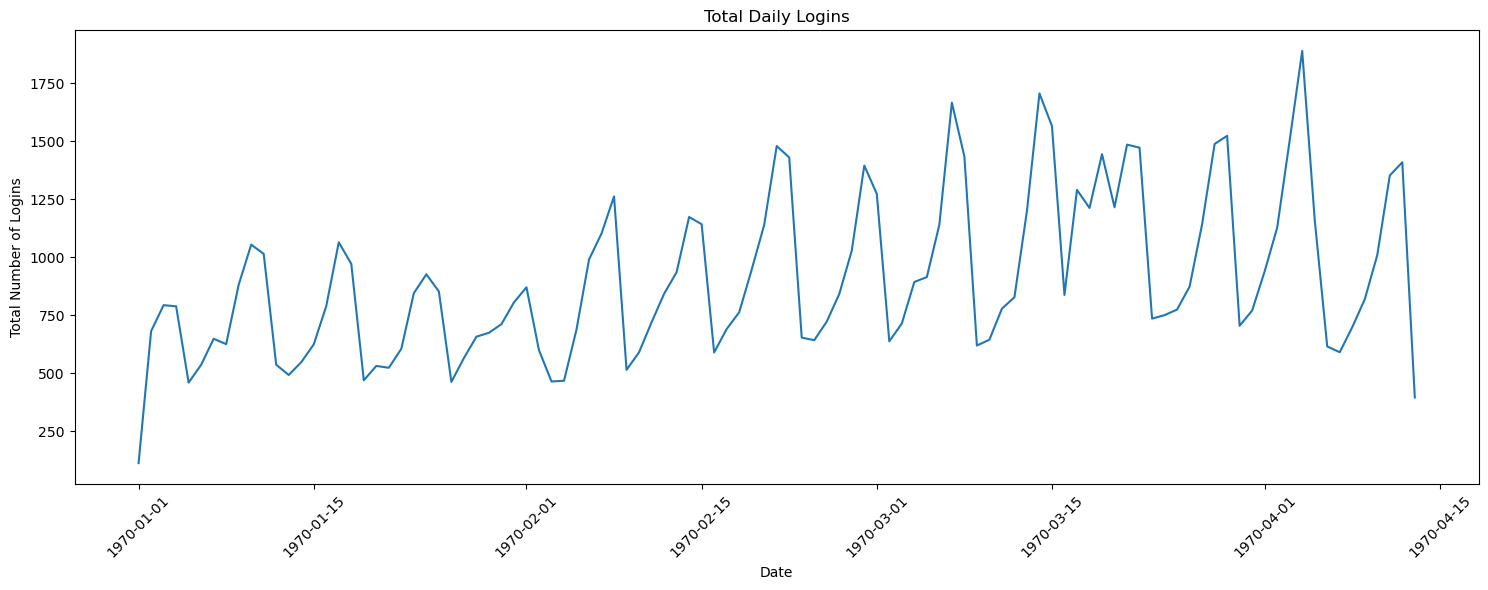

In [44]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_logins.index,
    daily_logins.values
)

plt.title('Total Daily Logins')
plt.xlabel('Date')
plt.ylabel('Total Number of Logins')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

##### Observations 

1. Daily login counts generally fluctuate between approximately 500 and 1,500 logins, although several days show substantially higher or lower values.
2. The data exhibit a repeating cyclical pattern, with regular increases and decreases in daily login activity rather than a smooth or consistent trend over time.
3. Overall daily demand appears to increase somewhat from January into March and early April, with some of the highest daily login counts occurring during this later period.
4. The highest observed daily login count occurs in early April, reaching approximately 1,900 logins.
5. Several sharp drops follow periods of high login activity, which is consistent with the strong day-of-week patterns observed in the earlier analysis.
6. There does not appear to be a sustained linear upward or downward trend across the entire time period. Instead, login demand is primarily characterized by regular cyclical fluctuations and periodic spikes.

In [46]:
# Check for unusually large gaps between logins
logins = logins.sort_values('login_time').reset_index(drop=True)

In [47]:
logins['time_difference'] = logins['login_time'].diff()

In [48]:
logins.nlargest(10, 'time_difference')

,login_time,time_difference
4402,1970-01-08 16:25:47,0 days 01:31:41
35879,1970-02-19 09:12:46,0 days 01:20:08
14303,1970-01-22 08:25:12,0 days 01:07:38
13738,1970-01-21 06:57:06,0 days 01:06:55
28306,1970-02-10 07:27:59,0 days 01:05:39
47316,1970-03-02 07:08:36,0 days 01:04:17
9325,1970-01-15 08:13:13,0 days 01:02:32
13181,1970-01-20 06:57:25,0 days 01:01:48
23781,1970-02-05 06:13:01,0 days 01:00:44
23250,1970-02-04 07:00:17,0 days 00:59:41


In [49]:
logins['time_difference'].describe()

count                        93141
mean     0 days 00:01:34.569759826
std      0 days 00:02:50.128176488
min                0 days 00:00:00
25%                0 days 00:00:17
50%                0 days 00:00:45
75%                0 days 00:01:46
max                0 days 01:31:41
Name: time_difference, dtype: object

##### Observations

1. The dataset contains 93,141 time intervals between consecutive login events.
2. The average time between logins is approximately 1 minute and 35 seconds, while the median time difference is 45 seconds.
3. Half of all consecutive logins occur within 45 seconds or less, indicating that login activity is generally frequent.
4. The 75th percentile time difference is approximately 1 minute and 46 seconds, meaning that 75% of consecutive logins occur less than two minutes apart.
5. The largest observed gap between consecutive logins is approximately 1 hour and 32 minutes.
   
Overall, there are no gaps spanning multiple hours or days, suggesting that there are no obvious extended periods of missing login data

## Part 2 - Experiment and metrics design 

The neighboring cities of Gotham and Metropolis have complementary circadian rhythms: on
weekdays, Ultimate Gotham is most active at night, and Ultimate Metropolis is most active
during the day. On weekends, there is reasonable activity in both cities.
However, a toll bridge, with a two way toll, between the two cities causes driver partners to tend
to be exclusive to each city. The Ultimate managers of city operations for the two cities have
proposed an experiment to encourage driver partners to be available in both cities, by
reimbursing all toll costs.

1) What would you choose as the key measure of success of this experiment in
encouraging driver partners to serve both cities, and why would you choose this metric?

##### Answer: 

The primary success metric should be the proportion of active driver partners who complete trips in both Gotham and Metropolis during a defined measurement period.

So for example, in a 1 week period, I would classify active drivers as the following:
a. Single-city driver: who completed trips only in Gotham or only in Metropolis
b. Multi-city driver: completed at least one trip in both cities 

then calculate:
multi-city driver rate = Number of drivers serving both cities (# of multi-city drivers)/Sum of (single-city drivers + multi-city drivers)

2) Describe a practical experiment you would design to compare the effectiveness of the
proposed change in relation to the key measure of success. Please provide details on:
a) how you will implement the experiment
b) what statistical test(s) you will conduct to verify the significance of the
observation
c) how you would interpret the results and provide recommendations to the city
operations team along with any caveats.

##### Answer: 

I would design a randomized controlled experiment 

1. Step 1: Define the eligible driver population. Select active driver partners who currently operate primarily in either Gotham or Metropolis. I would exclude drivers who already regularly serve both cities because the intervention is specifically trying to change the behavior of drivers who tend to remain exclusive to one city.

2. Step 2: Randomly assign eligible drivers into two groups:

a. Control group - Drivers continue operating under the existing system. They pay bridge tolls as usual.

b. Treatment group - Drivers receive reimbursement for eligible tolls when crossing between Gotham and Metropolis.

Random assignment helps ensure that, on average, the two groups are comparable before the experiment begins.

3. Step 3: Run the experiment long enough to capture multiple full weekly cycles—for example, 4–6 weeks. This is important because the cities have different weekday and weekend demand patterns.

The experiment should cover enough:
- weekdays,
- weekends,
- daytime periods, and
- nighttime periods

4. Step 4: Measure the outcome. For each driver, determine whether they completed trips in:

- Gotham only,
- Metropolis only, or
- both cities.

5. Step 5: Calculate the multi-city driver rate for the treatment and control groups.

The basic comparison would be:

Effect of reimbursement= Multi-city rate for treatment group - multicity rate for control group 

6. Step 6: Run a statistical test - Because the primary metric is a proportion, I would use a two-proportion z-test.
- Null Hypothesis: proportion of treatement drivers serving both cities = proportion of control drivers serving both cities (Toll reiumbursement has no effect on the population of drivers serving both cities)
- Alternative Hypothesis 1: proportion of treatement drivers serving both cities > proportion of control drivers serving both cities (Toll has a positive effect on encouraging drivers to operate in both cities)

7. Step 7: Interpretations and recommendations:

Scenario 1: Treatment group has a significantly higher multi-city driver rate (difference betweent the two is large and highly statistically signifiant which means we reject Null Hypothesis).
Interpretation: Toll reimbursement appears to successfully encourage drivers to operate in both cities.
Recommendation: Consider rollout more broadly, assuming the increase in cross-city driver activity is large enough to justify the cost of the reimbursement program.
 
Scenario 2: No statistically significant difference between the two proportions
Interpretation: There is insufficient evidence that toll reimbursement meaningfully changes the likelihood that drivers serve both cities.
Recommendation: Do not immediately roll out the reimbursement program. The company could investigate whether the reimbursement amount, communication strategy, or other barriers—such as driver preferences or differences in demand—are limiting cross-city participation.

Scenario 3: Treatment group has a significantly higher multi-city driver rate (difference betweent the two is small but statistically signifiant which means we reject Null Hypothesis).
Interpretation: The intervention has a statistically detectable effect, but the practical impact may be too small to justify the reimbursement costs.
Recommendation: Calculate the cost of toll reimbursements against potential benefits such as additional completed trips,
increased revenue, improved driver availability, reduced rider wait times.

8. Step 8: Caveats
a. Spillover effects- Drivers in the control group might still be indirectly affected by the treatment. For example, if treatment drivers increasingly cross into the other city, this could change driver supply and competition for trips, potentially affecting control drivers.

2. Driver communication and compliance- The treatment only works if drivers understand:
- which tolls are reimbursed,
- how reimbursement works,
- and that they are eligible.

Poor communication could make the treatment appear ineffective.

3. Experiment duration- The experiment should cover several full weekly cycles because driver behavior differs substantially between:
weekdays and weekends, daytime and nighttime.

A very short experiment could produce misleading results.

4. Cost-effectiveness- Even if the experiment increases multi-city driving, management should evaluate whether the additional activity justifies the reimbursement expense.

# Part 3 ‐ Predictive modeling

Ultimate is interested in predicting rider retention. To help explore this question, we have
provided a sample dataset of a cohort of users who signed up for an Ultimate account in
January 2014. The data was pulled several months later; we consider a user retained if they
were “active” (i.e. took a trip) in the preceding 30 days.

We would like you to use this data set to help understand what factors are the best predictors
for retention, and offer suggestions to operationalize those insights to help Ultimate.
The data is in the attached file ultimate_data_challenge.json. See below for a detailed
description of the dataset. Please include any code you wrote for the analysis and delete the
dataset when you have finished with the challenge.

1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided
data for this analysis (a few sentences/plots describing your approach will suffice). What
fraction of the observed users were retained?
2. Build a predictive model to help Ultimate determine whether or not a user will be active in
their 6th month on the system. Discuss why you chose your approach, what alternatives
you considered, and any concerns you have. How valid is your model? Include any key
indicators of model performance.
3. Briefly discuss how Ultimate might leverage the insights gained from the model to
improve its long term rider retention (again, a few sentences will suffice).

In [57]:
# Read in the data to a variable called df 
df = pd.read_json("./ultimate_data_challenge.json")

In [58]:
# Review data
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [59]:
# Review data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [60]:
# Check dimensions of the data 
df.shape

(50000, 12)

In [61]:
# Check missing values 
df.isnull().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

In [62]:
# Look at data types
df.dtypes

city                       object
trips_in_first_30_days      int64
signup_date                object
avg_rating_of_driver      float64
avg_surge                 float64
last_trip_date             object
phone                      object
surge_pct                 float64
ultimate_black_user          bool
weekday_pct               float64
avg_dist                  float64
avg_rating_by_driver      float64
dtype: object

In [63]:
# Convert the date columns
df['signup_date'] = pd.to_datetime(df['signup_date'])

df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

In [64]:
df.dtypes

city                              object
trips_in_first_30_days             int64
signup_date               datetime64[ns]
avg_rating_of_driver             float64
avg_surge                        float64
last_trip_date            datetime64[ns]
phone                             object
surge_pct                        float64
ultimate_black_user                 bool
weekday_pct                      float64
avg_dist                         float64
avg_rating_by_driver             float64
dtype: object

In [65]:
# Check date ranges 
print("Signup date range:")
print(df['signup_date'].min())
print(df['signup_date'].max())

print("\nLast trip date range:")
print(df['last_trip_date'].min())
print(df['last_trip_date'].max())

Signup date range:
2014-01-01 00:00:00
2014-01-31 00:00:00

Last trip date range:
2014-01-01 00:00:00
2014-07-01 00:00:00


In [66]:
# Define the observation date as the latest trip date
observation_date = df['last_trip_date'].max()

# Calculate the 30-day retention cutoff
retention_cutoff = observation_date - pd.Timedelta(days=30)

print("Observation date:", observation_date)
print("Retention cutoff:", retention_cutoff)

Observation date: 2014-07-01 00:00:00
Retention cutoff: 2014-06-01 00:00:00


In [67]:
# Create the retained binary variable (1= retained, 0= not retained) 

# A user is retained if their last trip was within the previous 30 days
df['retained'] = (
    df['last_trip_date'] >= retention_cutoff
).astype(int)

In [68]:
# Check the counts for the retained variable 
df['retained'].value_counts()

retained
0    31196
1    18804
Name: count, dtype: int64

In [69]:
# Calculate retention rate 
retention_rate = df['retained'].mean()

print(f"Fraction of users retained: {retention_rate:.2%}")

Fraction of users retained: 37.61%


##### Retention Rate

The retention outcome was defined based on whether a user's last_trip_date occurred within the 30 days preceding the latest observed trip date in the dataset (July 1, 2014). Users whose last trip occurred on or after June 1, 2014 were classified as retained.

Of the 50,000 users in the dataset, 18,804 users (37.61%) were retained, while 31,196 users (62.39%) were not retained. Therefore, fewer than half of the observed users remained active during the final 30-day observation period.

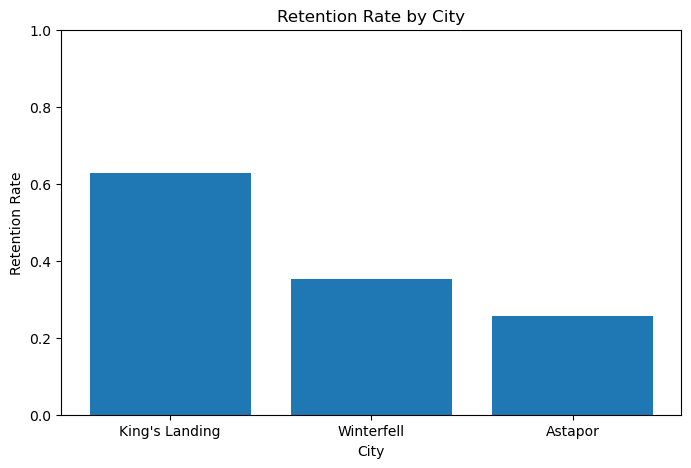

In [71]:
# Calculate retention rate by city and visualize 
city_retention = (
    df.groupby('city')['retained']
    .mean()
    .sort_values(ascending=False)
)

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    city_retention.index,
    city_retention.values
)

plt.title('Retention Rate by City')
plt.xlabel('City')
plt.ylabel('Retention Rate')

plt.ylim(0, 1)

plt.show()

In [72]:
# Retentian rate by phone type 
# Create a copy of phone with missing values labeled
df['phone_group'] = df['phone'].fillna('Missing')

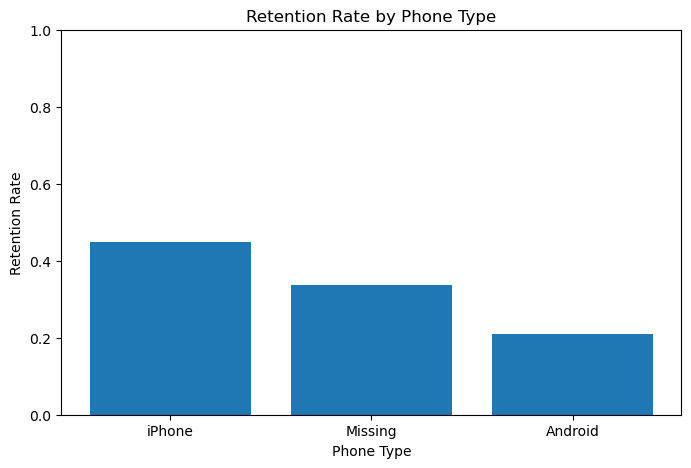

In [73]:
# Calculate retention rate by phone type
phone_retention = (
    df.groupby('phone_group')['retained']
    .mean()
    .sort_values(ascending=False)
)

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    phone_retention.index,
    phone_retention.values
)

plt.title('Retention Rate by Phone Type')
plt.xlabel('Phone Type')
plt.ylabel('Retention Rate')

plt.ylim(0, 1)

plt.show()

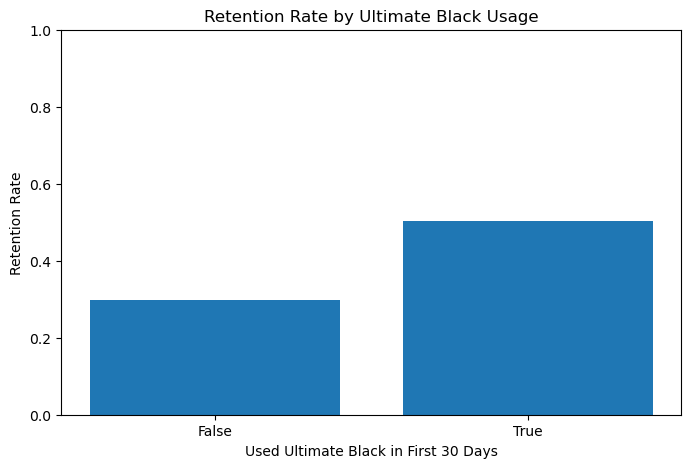

In [74]:
# Calculate retention rate by Ultimate Black usage
black_retention = (
    df.groupby('ultimate_black_user')['retained']
    .mean()
)

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    black_retention.index.astype(str),
    black_retention.values
)

plt.title('Retention Rate by Ultimate Black Usage')
plt.xlabel('Used Ultimate Black in First 30 Days')
plt.ylabel('Retention Rate')

plt.ylim(0, 1)

plt.show()

#### Observations from Initial Exploratory Analysis

The exploratory analysis identified several notable differences in retention rates across user groups:

1. City: Retention varies substantially by city. Users from King's Landing have the highest retention rate at approximately 63%, compared with approximately 36% in Winterfell and 26% in Astapor. This suggests that city may be an important predictor of long-term retention.
2. Phone type: Users with an iPhone have a substantially higher retention rate (approximately 45%) than users with an Android device (approximately 21%). Users with missing phone information have an intermediate retention rate of approximately 34%. This indicates that phone type may also contain useful predictive information.
3. Ultimate Black usage: Users who used Ultimate Black during their first 30 days had a retention rate of approximately 51%, compared with approximately 30% among users who did not use the service. This suggests an association between early Ultimate Black usage and higher long-term retention.

Overall, these exploratory results suggest that city, phone type, and early use of Ultimate Black may be useful predictors of rider retention. These variables will therefore be included in the predictive modeling analysis in Question 2.

### Question 2: I would approach this by developing and comparing two models: 

1. Logistic Regression — a simple, interpretable baseline.
2. Random Forest Classifier — can capture nonlinear relationships and interactions.

In [77]:
# Define predictor variables (X) and target variable (y)
X = df.drop(
    columns=[
        'retained',
        'retention_status',
        'last_trip_date',
        'signup_date'
    ],
    errors='ignore'
)

y = df['retained']

In [78]:
print(X.columns)

print(X.shape)

Index(['city', 'trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge',
       'phone', 'surge_pct', 'ultimate_black_user', 'weekday_pct', 'avg_dist',
       'avg_rating_by_driver', 'phone_group'],
      dtype='object')
(50000, 11)


In [79]:
# Check class balance
y.value_counts(normalize=True)

retained
0    0.62392
1    0.37608
Name: proportion, dtype: float64

##### Note - We can see some moderate class imbalance 

In [81]:
# Train-test split. I will stratify on y to maintain balance between training and test datasets 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [82]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (40000, 11)
Testing set shape: (10000, 11)

Training target distribution:
retained
0    0.623925
1    0.376075
Name: proportion, dtype: float64

Testing target distribution:
retained
0    0.6239
1    0.3761
Name: proportion, dtype: float64


In [83]:
# Define categorical and numerical features 
categorical_features = [
    'city',
    'phone',
    'ultimate_black_user'
]

numerical_features = [
    'trips_in_first_30_days',
    'avg_rating_of_driver',
    'avg_surge',
    'surge_pct',
    'weekday_pct',
    'avg_dist',
    'avg_rating_by_driver'
]

In [84]:
print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['city', 'phone', 'ultimate_black_user']

Numerical features:
['trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge', 'surge_pct', 'weekday_pct', 'avg_dist', 'avg_rating_by_driver']


In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [86]:
# Create a pre-processing pipeline. 
# For numerical variables, we will impute missing values using the median and scale them using StandardScaler 
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [87]:
# For categorical variables, we will inpute using the mode category and one-hot encode them
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [88]:
# Combine to create the pre-processor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Model 1: Baseline Logistic Regression 

In [158]:
from sklearn.linear_model import LogisticRegression

In [160]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [162]:
# Train the model 
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'phone',
                                                   'ultimate_black_user'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [164]:
# Predicted classes
y_pred_logistic = logistic_model.predict(X_test)

# Predicted probabilities
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [168]:
# Evaluate the model 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [170]:
# Print the evaluation metrics 
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))

Accuracy: 0.7148
Precision: 0.6635480388629004
Recall: 0.4902951342727998
F1 Score: 0.563914373088685
ROC-AUC: 0.7537183123765523


In [172]:
# Generate the classification report 
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.73      0.85      0.79      6239
           1       0.66      0.49      0.56      3761

    accuracy                           0.71     10000
   macro avg       0.70      0.67      0.68     10000
weighted avg       0.71      0.71      0.70     10000



In [176]:
# Create confusion matrix 
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print(cm_logistic)

[[5304  935]
 [1917 1844]]


##### Observations from the logistic regression model 

1. Accuracy = 71.5%: The model correctly classified about 71.5% of users overall.
2. Precision = 66.4%: When the model predicts that a user will be retained, it is correct about two-thirds of the time.
3. Recall = 49.0%: The model identifies only about half of the users who were actually retained.
4. F1 score = 56.4%: This reflects a moderate balance between precision and recall.
5. ROC-AUC = 0.754: The model has a reasonable ability to distinguish between retained and non-retained users.
   
From the confusion matrix, I observe that the model correctly identifies:

5,304 non-retained users
1,844 retained users

However, it incorrectly classifies 1,917 retained users as not retained. This explains the relatively low recall for the retained class.

So the model is noticeably better at identifying users who will not be retained than users who will be retained.

### Model 2: Random Forest Classifier 


In [180]:
from sklearn.ensemble import RandomForestClassifier

In [182]:
# Create the pipeline 
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [186]:
# Fit the model 
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'phone',
                                                   'ultimate_black_user'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [187]:
# Predicted classes
y_pred_rf = random_forest_model.predict(X_test)

# Predicted probabilities
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [190]:
# Print the evaluation metrics 
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7581
Precision: 0.685666851134477
Recall: 0.6588673225206062
F1 Score: 0.672
ROC-AUC: 0.8264084165957132


In [192]:
# Generate classification report 
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      6239
           1       0.69      0.66      0.67      3761

    accuracy                           0.76     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.76      0.76      0.76     10000



In [194]:
# Generate confusion matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[5103 1136]
 [1283 2478]]


##### Observations on the Random Forest Model Performance

The Random Forest model demonstrated stronger predictive performance than the Logistic Regression baseline across all major evaluation metrics.

1. The model achieved an accuracy of 75.8%, correctly classifying approximately three-quarters of users in the test set.
2. The precision for retained users was 68.6%, meaning that when the model predicted a user would be retained, the prediction was correct approximately 69% of the time.
3. The recall was 65.9%, indicating that the model successfully identified approximately two-thirds of users who were actually retained.
4. The F1 score was 0.672, representing a better balance between precision and recall than the Logistic Regression model.
5. The model achieved an ROC-AUC score of 0.826, indicating good ability to distinguish between users who were retained and those who were not retained.

The confusion matrix shows that the model correctly identified 5,103 non-retained users and 2,478 retained users. It produced 1,136 false positives and 1,283 false negatives.

##### Conclusion:

Overall, the Random Forest model provides a substantial improvement over the Logistic Regression baseline, particularly in identifying retained users. The Logistic Regression model had a recall of approximately 49% for retained users, while the Random Forest improved recall to approximately 66%. The Random Forest also achieved higher accuracy, F1 score, and ROC-AUC, suggesting that it is better able to capture potentially nonlinear relationships and interactions among the user characteristics.

Based on these initial results, the Random Forest appears to be the stronger model and is a good candidate for further evaluation and interpretation.

### Question 3: Leveraging Model Insights to Improve Rider Retention

The predictive model can help Ultimate identify users who may be at higher risk of not being retained and allow the company to target retention efforts more effectively. The exploratory analysis suggests that factors such as the user's city, phone type, and early use of Ultimate Black are associated with meaningful differences in retention rates.

Ultimate could use these insights to identify users with characteristics associated with lower retention and target them with interventions such as promotional offers, discounts, personalized incentives, or reminders to encourage continued use of the platform. The model could also help identify behaviors associated with higher retention. For example, the higher retention rate among users who used Ultimate Black during their first 30 days suggests that encouraging early engagement with premium services may be worth further investigation.

However, these relationships should not be interpreted as causal. For example, users who choose Ultimate Black may already differ from other users in ways that make them more likely to remain active. Therefore, Ultimate should use the model primarily to identify and target users at risk of churn, while testing specific retention strategies through controlled experiments to determine which interventions actually improve long-term retention.